# Análise Fatorial Exploratória (AFE)

## O que é e para que serve?

A **Análise Fatorial Exploratória** é uma técnica estatística que busca identificar **variáveis latentes** (invisíveis/ocultas) que explicam os padrões de correlação observados entre várias variáveis medidas.

### Diferença chave entre FA e PCA:
- **PCA** (Analyze Componentes Principais): é um método puramente matemático de compressão de dados. Ele cria novos eixos que maximizam a variância, sem implicação causal.
- **AFE** (Análise Fatorial): é um **modelo causal**. Parte da premissa de que existem "fatores latentes" que *causam* os padrões observados nas variáveis medidas.

### Objetivo deste notebook:
Dado um dataset de notas de 4 disciplinas de 8 alunos, queremos descobrir se existem **2 construtos latentes** (fatores) que explicam o desempenho:
- **Fator 1** → "Perfil Exatas" (Finanças + Atuária)
- **Fator 2** → "Perfil Humanas/Gestão" (Marketing + Liderança)

### O que você vai aprender a fazer:
1. Verificar se os dados são adequados para FA (testes de Bartlett e KMO)
2. Determinar quantos fatores extrair (Critério de Kaiser)
3. Aplicar rotação Varimax para facilitar a interpretação
4. Ler as cargas fatoriais para entender quais variáveis carregam em cada fator
5. Avaliar as comunalidades (quanto da variância de cada variável é explicada pelos fatores)

In [14]:
import pandas as pd  # Importa a biblioteca pandas para manipulação de dados tabulares
import numpy as np  # Importa a biblioteca numpy para operações numéricas e arrays
import matplotlib.pyplot as plt  # Importa o matplotlib para criação de visualizações gráficas
import seaborn as sns  # Importa o seaborn para visualização estatística de dados
from factor_analyzer import FactorAnalyzer  # Importa a classe FactorAnalyzer para análise fatorial
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo  # Importa funções para calcular testes de adequação (Bartlett e KMO)

import warnings  # Importa o módulo warnings para controle de mensagens de aviso
warnings.filterwarnings("ignore")  # Suprime todos os warnings do Python para manter a saída limpa
%matplotlib inline


## Passo 1: O Dataset de Notas

### O que são estes dados?
Temos **8 alunos** com notas (escala 0-10) em **4 disciplinas**:
- **Finanças** e **Atuária** → disciplinas de Exatas/Matemática
- **Marketing** e **Liderança** → disciplinas de Humanas/Gestão

### Observação importante:
Notas altas em Finanças tendem a acompanhar notas altas em Atuária (ambas Exatas).
Notas altas em Marketing tendem a acompanhar notas altas em Liderança (ambas Humanas).

**A pergunta que a Análise Fatorial vai responder:**
Será que a correlação entre estas disciplinas é explicada por **2 fatores latentes** subjacentes (Perfil Exatas e Perfil Humanas), ou cada disciplina é independente?

In [15]:
dados_notas = {  # Dicionário com as notas dos alunos em cada disciplina
    'financas': [8.0, 7.5, 4.0, 9.0, 5.0, 8.5, 4.5, 9.5],  # Notas dos alunos na disciplina de Finanças
    'atuaria': [8.5, 7.0, 3.5, 9.5, 4.0, 9.0, 3.0, 8.5],  # Notas dos alunos na disciplina de Atuária
    'marketing': [5.0, 6.0, 9.0, 4.5, 8.5, 5.5, 9.5, 6.0],  # Notas dos alunos na disciplina de Marketing
    'lideranca': [5.5, 5.0, 8.5, 5.0, 9.0, 4.5, 9.0, 5.5]  # Notas dos alunos na disciplina de Liderança
}  # Fecha o dicionário de dados

df_notas = pd.DataFrame(dados_notas)  # Cria um DataFrame pandas a partir do dicionário de notas
display(df_notas.head())  # Exibe as 5 primeiras linhas do DataFrame de notas

,financas,atuaria,marketing,lideranca
0,8.0,8.5,5.0,5.5
1,7.5,7.0,6.0,5.0
2,4.0,3.5,9.0,8.5
3,9.0,9.5,4.5,5.0
4,5.0,4.0,8.5,9.0


## Passo 2: Testes de Adequação da Amostra

### Por que precisamos testar os dados?
Antes de rodar a Análise Fatorial, precisamos provar estatisticamente que:
1. As variáveis **estão correlacionadas** entre si (se não houver correlação, não há fator latente)
2. A amostra é **adequada** para extração de fatores

### Os dois testes:
**1. Teste de Esfericidade de Bartlett**
- Testa se a matriz de correlação é diferente da matriz identidade
- Hipótese nula: as variáveis são independentes (não há FA possível)
- **Queremos**: p-valor **< 0.05** (rejeitar a nulidade → existe correlação)

**2. Teste KMO (Kaiser-Meyer-Olkin)**
- Mede a proporção da variância que é "variância comum" (explicável por fatores)
- Escala de 0 a 1
- **Interpretação**: > 0.6 (aceitável) | > 0.8 (bom) | > 0.9 (excelente)
**> 0.5** (medíocre) | **< 0.5** (inaceitável para FA)

In [16]:
# --- Teste de Bartlett ---
chi_square_value, p_value = calculate_bartlett_sphericity(df_notas)  # Calcula a estatística e o p-valor do teste de esfericidade de Bartlett
print(f"Teste de Esfericidade de Bartlett (p-value): {p_value:.5f}")  # Imprime o p-valor do teste de Bartlett

# --- Teste KMO ---
kmo_all, kmo_model = calculate_kmo(df_notas)  # Calcula o KMO (Kaiser-Meyer-Olkin) para avaliar a adequação da amostra
print(f"KMO Geral da Amostra: {kmo_model:.3f}")  # Imprime o valor KMO geral da amostra

Teste de Esfericidade de Bartlett (p-value): 0.00000
KMO Geral da Amostra: 0.779


### O que observar na saída:
- **Bartlett p-value < 0.05** → as variáveis são significativamente correlacionadas → FA é válida ✅
- **KMO > 0.6** → a amostra é adequada para FA ✅

Se qualquer um desses critérios falhar, a Análise Fatorial **não é apropriada** para estes dados.

### Como interpretar o Scree Plot:

Olhe para a **tabela de autovalores** impressa na célula anterior:
- **Fator 1**: Autovalor `> 1` → **Retém** (explica mais variância que uma variável isolada)
- **Fator 2**: Autovalor `< 1` → **Descarta** (não justifica a extração)

O gráfico de autovalores (Scree Plot) é gerado para **visualização**, mas os dados reais estão na tabela acima.

**Neste exemplo, reter apenas 1 fator com autovalor > 1.**

⚠️ **Atenção:** O Critério de Kaiser é uma regra empírica, não uma lei absoluta. Sempre combine com a interpretação teórica e considere também a interpretação prática dos fatores.

Fator 1: Autovalor = 3.8487 > 1 (reter)
Fator 2: Autovalor = 0.0833 < 1 (descartar)
Fator 3: Autovalor = 0.0592 < 1 (descartar)
Fator 4: Autovalor = 0.0088 < 1 (descartar)


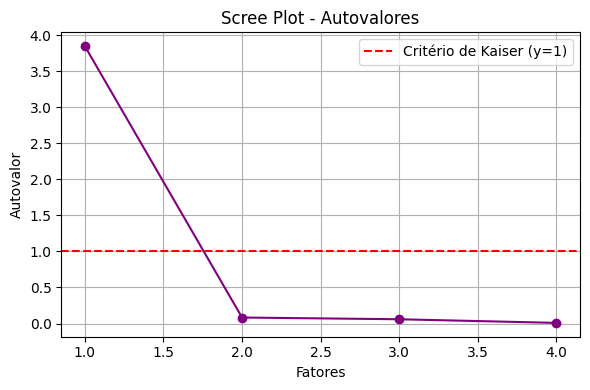

In [20]:
# Inicializa o analisador fatorial com todos os fatores possíveis e sem rotação (apenas para extrair autovalores)
fa_inicial = FactorAnalyzer(n_factors=df_notas.shape[1], rotation=None)  # n_factors = número de variáveis (4)
fa_inicial.fit(df_notas)  # Ajusta o modelo fatorial aos dados de notas

# Extrai os autovalores (ev) e autovetores (v)
ev, v = fa_inicial.get_eigenvalues()  # ev = autovalores, v = autovetores

# Exibe os autovalores como texto para referência
for idx, val in enumerate(ev, start=1):  # Itera sobre autovalores com índice
    status = ' > 1 (reter)' if val > 1 else ' < 1 (descartar)'  # Critério de Kaiser
    print(f"Fator {idx}: Autovalor = {val:.4f}{status}")  # Imprime cada autovalor

# Cria o Scree Plot (gráfico de autovalores)
fig, ax = plt.subplots(figsize=(6,4))  # Cria figura com tamanho 6x4
ax.plot(range(1, len(ev)+1), ev, marker='o', color='purple')  # Plota autovalores
ax.axhline(y=1, color='r', linestyle='--', label='Critério de Kaiser (y=1)')  # Linha y=1
ax.set_title('Scree Plot - Autovalores')  # Título do gráfico
ax.set_xlabel('Fatores')  # Rótulo do eixo x
ax.set_ylabel('Autovalor')  # Rótulo do eixo y
ax.legend()  # Legenda
ax.grid(True)  # Grade
plt.tight_layout()  # Ajusta o layout
plt.show()  # Renderiza e exibe o gráfico


### Como interpretar o Scree Plot:
1. Veja no gráfico quais autovalores estão **acima da linha vermelha y=1**
2. Conte quantos fatores ficam acima dessa linha
3. Neste exemplo, **2 fatores** terão autovalor > 1 → extraiamos 2 fatores

⚠️ **Atenção:** O Critério de Kaiser é uma regra empírica, não uma lei absoluta. Sempre combine com a interpretação teórica.

## Passo 4: Rotação Varimax e Cargas Fatoriais

### Por que rotacionar?
Quando extraímos fatores sem rotação, a carga de cada variável nos fatores pode ser difícil de interpretar (uma mesma variável pode aparecer associada a múltiplos fatores).

A **Rotação Varimax** é uma rotação **ortogonal** (os fatores permanecem independentes entre si) que:
- **Maximiza** a carga de cada variável em **um único fator**
- **Minimiza** a carga da mesma variável nos **outros fatores**
- O resultado: cada variável "carrega" fortemente em apenas um fator → interpretação mais clara

Cargas Fatoriais:
            Fator 1   Fator 2
financas  -0.583673  0.793211
atuaria   -0.709943  0.700634
marketing  0.818212 -0.570298
lideranca  0.706499 -0.641594


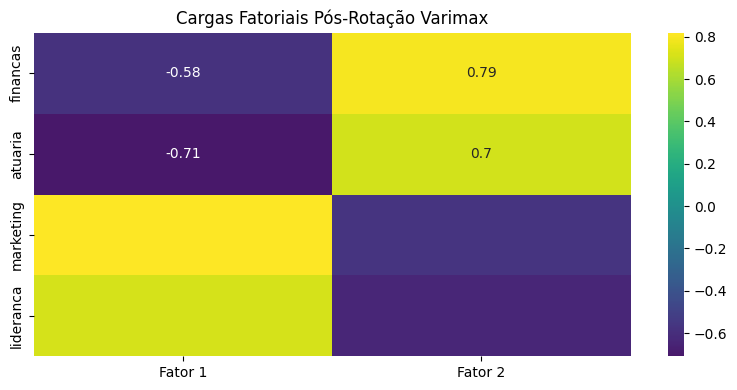

In [18]:
# Ajusta o modelo final com 2 fatores e rotação Varimax
fa_final = FactorAnalyzer(n_factors=2, rotation='varimax')  # 2 fatores + rotação Varimax
fa_final.fit(df_notas)  # Ajusta o modelo fatorial final aos dados

# Obtém as cargas fatoriais (correlações entre variáveis originais e fatores)
cargas = pd.DataFrame(
    fa_final.loadings_,  # Matriz de cargas fatoriais do modelo
    index=df_notas.columns,  # Nomes das disciplinas como índice das linhas
    columns=['Fator 1', 'Fator 2']  # Nomes das colunas para os dois fatores
)  # Cria DataFrame com as cargas fatoriais, indexado pelos nomes das variáveis

# Exibe as cargas como texto para referência
print("Cargas Fatoriais:")  # Cabeçalho
print(cargas.to_string())  # Imprime a tabela de cargas

# Visualiza as cargas como heatmap
fig, ax = plt.subplots(figsize=(8, 4))  # Cria figura com tamanho 8x4
sns.heatmap(cargas, annot=True, cmap='viridis', center=0, ax=ax)  # Heatmap com anotações
ax.set_title('Cargas Fatoriais Pós-Rotação Varimax')  # Título
plt.tight_layout()  # Ajusta layout
plt.show()  # Exibe o gráfico


### Como ler o Heatmap de Cargas Fatoriais:

| Carga | Significado |
|-------|-------------|
| **> 0.7** | Forte associação (variável pertence fortemente ao fator) |
| **0.4 - 0.7** | Associação moderada |
| **< 0.4** | Associação fraca (variável não é bem explicada pelo fator) |

### Interpretação esperada:
- **Fator 1** → carrega fortemente em **Finanças** e **Atuária**
  → Podemos chamar este fator de **"Perfil Exatas"** 🔢
- **Fator 2** → carrega fortemente em **Marketing** e **Liderança**
  → Podemos chamar este fator de **"Perfil Humanas/Gestão"** 📊

**Nota:** Se uma variável carrega em dois fatores com valores semelhantes, pode ser que a rotação precisa de mais iterações ou que a variável é um "híbrido" entre os dois construtos.

## Passo 5: Comunalidades

### O que é Comunalidade?
A **Comunalidade** (h²) indica a **proporção da variância** de cada variável original que é explicada pelos fatores latentes que extraímos.

### Interpretação:
| Valor | Significado |
|-------|-------------|
| **≈ 1.0** | O fator explica praticamente toda a variância da variável ✅ |
| **0.6 - 0.9** | O fator explica uma boa parte da variância ✅ |
| **< 0.5** | O fator explica pouca variância → a variável não está bem representada ⚠️ |

### O que observar:
- Se uma variável tem comunalidade muito baixa, ela pode não estar relacionada aos fatores extraídos
- Comunalidades altas geralmente indicam que o modelo fatorial capturou bem a estrutura dos dados

In [19]:
# Calcula as comunalidades (proporção da variância explicada pelos 2 fatores)
comunalidades = pd.DataFrame(
    fa_final.get_communalities(),  # Obtém array de comunalidades
    index=df_notas.columns,  # Nomes das disciplinas como índice
    columns=['Comunalidade']  # Nome da coluna
)  # Cria DataFrame com as comunalidades

# Exibe as comunalidades como texto
print("Comunalidades:")  # Cabeçalho
print(comunalidades.to_string())  # Imprime a tabela

display(comunalidades)  # Exibe a tabela de comunalidades no notebook

Comunalidades:
           Comunalidade
financas       0.969858
atuaria        0.994907
marketing      0.994711
lideranca      0.910785


,Comunalidade
financas,0.969858
atuaria,0.994907
marketing,0.994711
lideranca,0.910785


## Resumo do que aprendemos

| Etapa | O que fizemos | Resultado |
|-------|--------------|----------|
| 1 | Importou as bibliotecas | Ambiente pronto para FA |
| 2 | Criou o dataset de notas | 8 alunos, 4 disciplinas |
| 3 | Testouadequação (Bartlett + KMO) | Dados são adequados para FA ✅ |
| 4 | Extraiu autovalores (Critério de Kaiser) | 2 fatores a reter (autovalor > 1) |
| 5 | Aplicou rotação Varimax | Cargas fatoriais claras e interpretáveis |
| 6 | Analisou comunalidades | Variáveis bem representadas pelos fatores |

### Próximos passos:
- Validar os fatores com mais dados (amostra maior)
- Testar outras rotações (Oblimin para fatores correlacionados)
- Comparar com os resultados do PCA (Análise de Componentes Principais) para ver se os fatores coincidem